# Clasificación de semillas con SVM

Trabajo práctico — Tecnicatura Superior en Ciencia de Datos e IA.

Clasificación multiclase de variedades de semillas de trigo (dataset *Seeds*, UCI Machine Learning Repository) usando Support Vector Machines. Se entrena y compara un modelo con kernel lineal contra uno con kernel RBF, se visualizan las fronteras de decisión y se interpretan los coeficientes del modelo lineal.

Ver el README.md del repositorio para el resumen ejecutivo del proyecto.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# Importaciones de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
# Herramienta para dibujar las fronteras del SVM
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
import requests

# URL correcta del repositorio de la UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'
response = requests.get(url)

with open('seeds_dataset.txt', 'wb') as f:
    f.write(response.content)

print('Archivo seeds_dataset.txt descargado correctamente desde la web.')

Archivo seeds_dataset.txt descargado correctamente desde la web.


In [ ]:
# 1. CARGA DE DATOS Y ENTRENAMIENTO
# ==========================================

archivo_local = "/content/seeds_dataset.txt"
column_names = ["Area", "Perimeter", "Compactness", "Length", "Width", "Asymmetry_Coeff", "Groove_Length", "Class"]
df = pd.read_csv(archivo_local, sep=r'\s+', header=None, names=column_names)

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Modelo principal (7D)
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)
accuracy_porcentaje = accuracy_score(y_test, y_pred) * 100

In [ ]:
# Comparativa de Kernels
models = {
    'Lineal': SVC(kernel='linear', C=1.0, random_state=42),
    'RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test) * 100
    print(f'Precisión con Kernel {name}: {acc:.2f}%')

Precisión con Kernel Lineal: 90.48%
Precisión con Kernel RBF: 90.48%


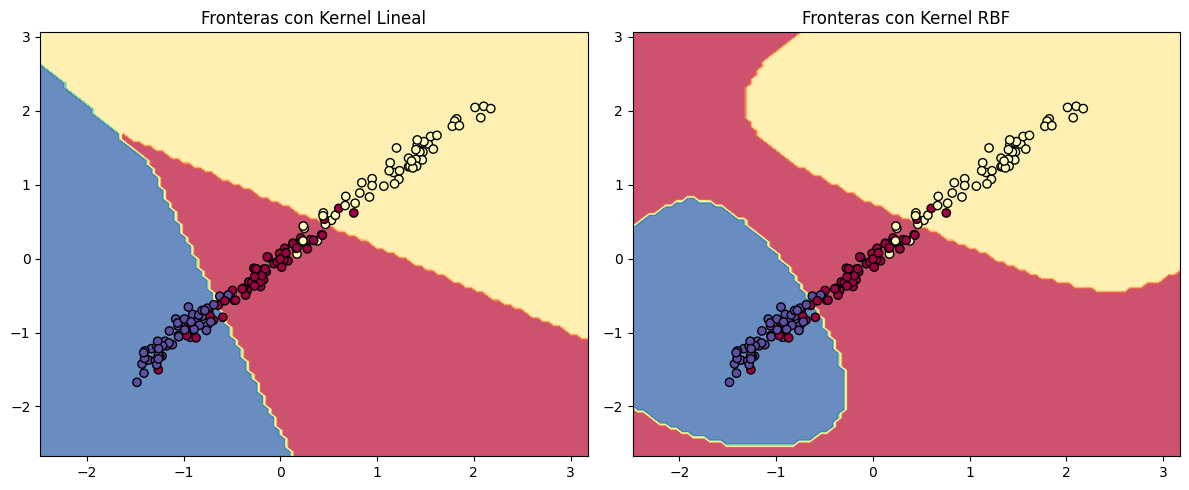

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

# Usaremos solo las dos primeras variables para la visualización en 2D
X_vis = X_train_scaled[:, :2]
y_vis = y_train

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for name, kernel, ax in zip(['Lineal', 'RBF'], ['linear', 'rbf'], [ax1, ax2]):
    clf = SVC(kernel=kernel, C=1.0).fit(X_vis, y_vis)
    DecisionBoundaryDisplay.from_estimator(
        clf, X_vis, response_method="predict",
        cmap=plt.cm.Spectral, alpha=0.8, ax=ax
    )
    ax.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolors="k", cmap=plt.cm.Spectral)
    ax.set_title(f'Fronteras con Kernel {name}')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Definimos los enfrentamientos que hizo el modelo (Uno vs Uno)
# Asumiendo que las clases son 1 (Kama), 2 (Rosa), 3 (Canadian)
enfrentamientos = ["Kama vs Rosa", "Kama vs Canadian", "Rosa vs Canadian"]

# 2. Obtenemos los nombres de tus 7 atributos (excluyendo 'Class')
atributos = column_names[:-1]

# 3. Extraemos los pesos y el sesgo del modelo entrenado
pesos = svm_model.coef_
sesgos = svm_model.intercept_

# 4. Armamos un DataFrame para verlo como una tabla ordenada
df_pesos = pd.DataFrame(pesos, columns=atributos, index=enfrentamientos)
df_pesos['SESGO (Bias)'] = sesgos

# Mostramos los resultados
print("Pesos y Sesgo para cada atributo en los 3 hiperplanos:")
print("-" * 60)
print(df_pesos.round(4)) # Redondeamos a 4 decimales para que quede prolijo

Pesos y Sesgo para cada atributo en los 3 hiperplanos:
------------------------------------------------------------
                    Area  Perimeter  Compactness  Length   Width  \
Kama vs Rosa     -0.4522    -0.5099       0.1450  1.3145 -0.6115   
Kama vs Canadian  0.9319     0.9981       0.6149  1.0833  0.7335   
Rosa vs Canadian  0.4172     0.4146       0.3347  0.3014  0.4683   

                  Asymmetry_Coeff  Groove_Length  SESGO (Bias)  
Kama vs Rosa              -0.2216        -1.7905        0.5710  
Kama vs Canadian          -0.7222        -1.2684        1.8144  
Rosa vs Canadian          -0.2118         0.4168        0.3283  
